# ML Volatility Targets Creation (Step 1/2)

## Overview
This Jupyter Notebook generates 3 competing definitions of MARKET volatility targets (Y) for machine learning: Y_EWMA (RiskMetrics standard), Y_GARCH (theoretically optimal), and Y_REALIZED (ex-post ground truth). It prepares monthly volatility estimates for regime classification (HIGH_VOL vs LOW_VOL) and tactical allocation on 25 factors based on market volatility regimes.

## Key Features
- **Target Methods**: EWMA (λ=0.94, MA12 smoothing), GARCH(1,1)-QMLE with AIC-based order selection, Realized (12-month forward std).
- **Timing Protocol**: Fama-French convention (annual formations, monthly targets, no lookahead).
- **Regime Classification**: Binarization using expanding median (HIGH_VOL=1 if Y > median, LOW_VOL=0 otherwise).
- **Scope**: MARKET volatility only (not individual factors).

## Methodology
1. Load market EW returns from NYSE P20 benchmark.
2. Generate monthly volatility targets using 3 methods (backward for EWMA/GARCH, forward for REALIZED).
3. Binarize targets into HIGH_VOL/LOW_VOL regimes using expanding median.
4. Validate timing, burn-in, and no lookahead.
5. Visualize time series, correlations, and regime frequencies.

## Dependencies
- Libraries: pandas, numpy, matplotlib, seaborn, arch (for GARCH).
- Data: Market returns from data/ml_data/market/market_returns_ew_nys80.parquet.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Run cells to load data, generate targets, binarize, and validate.
2. Review visualizations and diagnostics.
3. Proceed to Notebook 07_2 for ML modeling and backtesting.

## Output Files
- **data/ml_data/volatility_targets/volatility_targets_y.parquet**: Parquet with Y_EWMA, Y_GARCH, Y_REALIZED (continuous), and Y_*_BINARY (binary) columns, indexed by monthly dates.

This notebook prepares volatility targets for ML-based regime prediction and tactical factor allocation.

In [32]:

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Optional, Literal
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model  # GARCH-QMLE
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("="*100)
print("📦 NOTEBOOK 07_1 : VOLATILITY TARGET GENERATION (MARKET ONLY)")
print("="*100)

📦 NOTEBOOK 07_1 : VOLATILITY TARGET GENERATION (MARKET ONLY)


In [33]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1  CONFIG)
# ════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ────────────────────────────────────────────────────────────────────────
    # TIMING PARAMETERS (FAMA-FRENCH CONVENTION)
    # ────────────────────────────────────────────────────────────────────────
    'timing': {
        'first_formation_year': 1969,       # First valid formation (burn-in validated)
        'formation_month': 6,               # June (Fama-French standard)
        'formation_day': 30,                # End of month
        'rebalancing_frequency': 'annual'   # Annual (aligned with Baskets 1-5)
    },
    
    # ────────────────────────────────────────────────────────────────────────
    # TARGET Y GENERATION METHODS
    # ────────────────────────────────────────────────────────────────────────
    'targets': {
        # METHOD 1 : EWMA (RiskMetrics Standard)
        'ewma': {
            'enabled': True,
            'lambda_decay': 0.94,           # RiskMetrics monthly standard
            'min_periods': 60,              # 5 years minimum history
            'ma_smoothing': 12,             # 12-month MA smoothing (reduce noise)
            'annualize': False              # Keep monthly scale
        },
        
        # METHOD 2 : GARCH (Theoretically Optimal)
        'garch': {
            'enabled': True,
            'p': 1,                         # GARCH lag order
            'q': 1,                         # ARCH lag order
            'distribution': 't',            # QMLE under t-distribution (robust)
            'min_periods': 60,              # 5 years minimum history
            'rescale': False,               # Keep decimal scale (not percentage)
            'max_iter': 1000,               # Convergence iterations
            'ftol': 1.0e-8                  # Convergence tolerance
        },
        
        # METHOD 3 : REALIZED (Ex-Post Truth)
        'realized': {
            'enabled': True,
            'horizon': 12,                  # 12-month forward horizon
            'method': 'std',                # Standard deviation (simple)
            'annualize': False              # Keep monthly scale
        }
    },
    
    # ────────────────────────────────────────────────────────────────────────
    # DATA PATHS
    # ────────────────────────────────────────────────────────────────────────
    'paths': {
        'portfolios_dir': 'data/portfolios',
        'output_dir': 'data/ml_data/volatility_targets',
        'output_filename': 'volatility_targets_y.parquet'
    },
    
    # ────────────────────────────────────────────────────────────────────────
    # MARKET RETURNS SOURCE
    # ────────────────────────────────────────────────────────────────────────
    'market': {
        'source_factor': 'debt_maturity',   # Any factor with ret_high_vw (market proxy)
        'returns_column': 'ret_high_vw'     # Value-weighted market returns
    },
    
    # ────────────────────────────────────────────────────────────────────────
    # VALIDATION CHECKS
    # ────────────────────────────────────────────────────────────────────────
    'validation': {
        'check_lookahead': True,            # Verify no future data used
        'check_burn_in': True,              # Verify sufficient history
        'min_formations': 30                # Minimum formations to proceed
    }
}

print(f"\n✅ Configuration loaded (hardcoded):")
print(f"\n📊 Active target methods:")
for method, params in CONFIG['targets'].items():
    status = "✅ Enabled" if params.get('enabled', True) else "❌ Disabled"
    print(f"   • {method.upper():<10} : {status}")

print(f"\n📅 Timing parameters:")
print(f"   • First formation : June {CONFIG['timing']['first_formation_year']}")
print(f"   • Frequency       : {CONFIG['timing']['rebalancing_frequency']}")

print(f"\n📊 Target specifications:")
print(f"   • EWMA   : λ={CONFIG['targets']['ewma']['lambda_decay']}, "
      f"window={CONFIG['targets']['ewma']['min_periods']}m, "
      f"MA({CONFIG['targets']['ewma']['ma_smoothing']})")
print(f"   • GARCH  : ({CONFIG['targets']['garch']['p']},{CONFIG['targets']['garch']['q']})-QMLE, "
      f"window={CONFIG['targets']['garch']['min_periods']}m")
print(f"   • REALIZED: {CONFIG['targets']['realized']['horizon']}m forward")

print(f"\n📁 Paths:")
print(f"   • Portfolios : {CONFIG['paths']['portfolios_dir']}")
print(f"   • Output     : {CONFIG['paths']['output_dir']}/{CONFIG['paths']['output_filename']}")

print(f"\n📈 Market source:")
print(f"   • Factor : {CONFIG['market']['source_factor']}")
print(f"   • Column : {CONFIG['market']['returns_column']}")

print("\n" + "="*100)


✅ Configuration loaded (hardcoded):

📊 Active target methods:
   • EWMA       : ✅ Enabled
   • GARCH      : ✅ Enabled
   • REALIZED   : ✅ Enabled

📅 Timing parameters:
   • First formation : June 1969
   • Frequency       : annual

📊 Target specifications:
   • EWMA   : λ=0.94, window=60m, MA(12)
   • GARCH  : (1,1)-QMLE, window=60m
   • REALIZED: 12m forward

📁 Paths:
   • Portfolios : data/portfolios
   • Output     : data/ml_data/volatility_targets/volatility_targets_y.parquet

📈 Market source:
   • Factor : debt_maturity
   • Column : ret_high_vw



In [34]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : LOAD MARKET RETURNS (EW - NYSE P20 BENCHMARK)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES MARKET RETURNS (EW - NYSE P20)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# Load market EW returns from pre-computed benchmark (Notebook 06_1)
# Source: NYSE P20 universe (excludes smallest 20% firms)
# Timing: Formation MAI year t, Holding JUL t → JUN t+1
# ════════════════════════════════════════════════════════════════════════════

MARKET_BENCHMARK_PATH = Path('data/ml_data/market/market_returns_ew_nys80.parquet')

if not MARKET_BENCHMARK_PATH.exists():
    raise FileNotFoundError(
        f"Market benchmark not found: {MARKET_BENCHMARK_PATH}\n"
        f"Please run notebook 06_1_ML_NYSEP20_EW_Benchmark_creation.ipynb first."
    )

# Load benchmark
market_df = pd.read_parquet(MARKET_BENCHMARK_PATH)
market_df['date'] = pd.to_datetime(market_df['date'])
market_df = market_df.sort_values('date').reset_index(drop=True)

# Extract returns series
market_returns = market_df.set_index('date')['ret_market_ew'].copy()
market_returns.name = 'Market_EW'

print(f"\n✅ Market EW returns loaded:")
print(f"   📁 Source    : NYSE P20 benchmark (pre-computed)")
print(f"   📂 Path      : {MARKET_BENCHMARK_PATH}")
print(f"   📅 Period    : {market_returns.index.min().date()} → {market_returns.index.max().date()}")
print(f"   🔢 Length    : {len(market_returns)} months")
print(f"   📊 Universe  : NYSE P20 (excludes smallest 20% firms)")

print(f"\n📈 Performance statistics:")
print(f"   • Mean       : {market_returns.mean()*100:.2f}% per month")
print(f"   • Std        : {market_returns.std()*100:.2f}% per month")
print(f"   • Sharpe     : {market_returns.mean() / market_returns.std() * np.sqrt(12):.2f} (annualized)")
print(f"   • Min        : {market_returns.min()*100:.2f}%")
print(f"   • Max        : {market_returns.max()*100:.2f}%")

# Annualized stats
cum_ret = (1 + market_returns.dropna()).prod() - 1
n_months = len(market_returns.dropna())
annual_ret = (1 + cum_ret) ** (12 / n_months) - 1
annual_vol = market_returns.std() * np.sqrt(12)

print(f"\n📊 Annualized performance:")
print(f"   • Cumulative : {cum_ret*100:.1f}%")
print(f"   • Annual ret : {annual_ret*100:.2f}%")
print(f"   • Annual vol : {annual_vol*100:.2f}%")
print(f"   • Sharpe     : {annual_ret / annual_vol:.2f}")

print("\n" + "="*100)

📦 CHARGEMENT DES MARKET RETURNS (EW - NYSE P20)

✅ Market EW returns loaded:
   📁 Source    : NYSE P20 benchmark (pre-computed)
   📂 Path      : data/ml_data/market/market_returns_ew_nys80.parquet
   📅 Period    : 1963-07-31 → 2024-06-28
   🔢 Length    : 732 months
   📊 Universe  : NYSE P20 (excludes smallest 20% firms)

📈 Performance statistics:
   • Mean       : 1.15% per month
   • Std        : 5.17% per month
   • Sharpe     : 0.77 (annualized)
   • Min        : -25.94%
   • Max        : 22.78%

📊 Annualized performance:
   • Cumulative : 160184.5%
   • Annual ret : 12.86%
   • Annual vol : 17.91%
   • Sharpe     : 0.72



In [35]:
# CELL 2.5 : NORMALIZE MARKET RETURNS INDEX (NEW CELL AFTER CELL 2)

print("="*100)
print("🔧 NORMALISATION DE L'INDEX TEMPOREL")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# NORMALIZE TO MONTH-END (HANDLE 28/29/30/31 INCONSISTENCIES)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 AVANT normalisation :")
print(f"   • Sample dates : {market_returns.index[:5].date.tolist()}")
print(f"   • Unique days  : {market_returns.index.day.unique()}")

# Convert to period (month) then back to timestamp (month-end)
market_returns.index = market_returns.index.to_period('M').to_timestamp('M')

print(f"\n✅ APRÈS normalisation :")
print(f"   • Sample dates : {market_returns.index[:5].date.tolist()}")
print(f"   • Unique days  : {market_returns.index.day.unique()}")
print(f"   • All month-end: {all(d in [28, 29, 30, 31] for d in market_returns.index.day)}")

# Verify no duplicates
if market_returns.index.duplicated().any():
    print(f"\n⚠️  WARNING : {market_returns.index.duplicated().sum()} duplicates detected, removing...")
    market_returns = market_returns[~market_returns.index.duplicated(keep='first')]

print(f"\n📊 Final index :")
print(f"   • Length : {len(market_returns)}")
print(f"   • Period : {market_returns.index.min().date()} → {market_returns.index.max().date()}")

print("\n" + "="*100)

🔧 NORMALISATION DE L'INDEX TEMPOREL

📊 AVANT normalisation :
   • Sample dates : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 30), datetime.date(1963, 9, 30), datetime.date(1963, 10, 31), datetime.date(1963, 11, 29)]
   • Unique days  : Index([31, 30, 29, 28, 26, 27], dtype='int32', name='date')

✅ APRÈS normalisation :
   • Sample dates : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 31), datetime.date(1963, 9, 30), datetime.date(1963, 10, 31), datetime.date(1963, 11, 30)]
   • Unique days  : Index([31, 30, 29, 28], dtype='int32', name='date')
   • All month-end: True

📊 Final index :
   • Length : 732
   • Period : 1963-07-31 → 2024-06-30



In [36]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : VOLATILITY TARGET GENERATOR CLASS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  VOLATILITY TARGET GENERATOR CLASS")
print("="*100)

class MarketVolatilityTargetGenerator:
    """
    Generate market volatility targets using 3 methods:
    
    1. EWMA (Exponentially Weighted Moving Average)
       - Standard: JP Morgan RiskMetrics (1996)
       - Parameters: λ=0.94 (monthly), window=60 months, MA smoothing
    
    2. GARCH (Generalized AutoRegressive Conditional Heteroskedasticity)
       - Estimation: QMLE (Quasi-Maximum Likelihood)
       - Robust: Bollerslev-Wooldridge standard errors
       - Specification: GARCH(1,1) standard
    
    3. REALIZED (Ex-Post Realized Volatility)
       - Ground truth: Forward 12-month standard deviation
       - Benchmark: Andersen & Bollerslev (1998)
    
    TIMING GUARANTEE:
    ------------------
    For formation date 30 June Year t:
       • Uses returns [July 1963 → May t] ONLY
       • ret_June_t NOT USED (not yet observed)
       • Target Y = volatility estimate at END of May t
       • NO LOOKAHEAD for EWMA and GARCH
       • REALIZED is forward-looking by construction (used in training only)
    
    Reference:
    ----------
    Engle (1982), Bollerslev (1986), JP Morgan (1996), Andersen & Bollerslev (1998)
    """
    
    def __init__(self, config: Dict):
        """
        Initialize generator with config parameters.
        
        Parameters:
        -----------
        config : dict
            Configuration dictionary (from YAML)
        """
        self.config = config
        self.ewma_config = config['targets']['ewma']
        self.garch_config = config['targets']['garch']
        self.realized_config = config['targets']['realized']
        
        # Derived parameters
        self.alpha_ewma = 1 - self.ewma_config['lambda_decay']
        
        print(f"✅ MarketVolatilityTargetGenerator initialized:")
        print(f"\n   📊 EWMA:")
        print(f"      • λ           : {self.ewma_config['lambda_decay']}")
        print(f"      • Window      : {self.ewma_config['min_periods']} months")
        print(f"      • MA smoothing: {self.ewma_config['ma_smoothing']} months")
        
        print(f"\n   📊 GARCH:")
        print(f"      • Model       : GARCH({self.garch_config['p']},{self.garch_config['q']})")
        print(f"      • Distribution: {self.garch_config['distribution']} (QMLE)")
        print(f"      • Min periods : {self.garch_config['min_periods']} months")
        
        print(f"\n   📊 REALIZED:")
        print(f"      • Horizon     : {self.realized_config['horizon']} months forward")
        print(f"      • Method      : {self.realized_config['method']}")
    
    
    def _get_history_cutoff(self, formation_date: pd.Timestamp) -> pd.Timestamp:
        """
        Get last date of available history (1 month before formation).
        
        Parameters:
        -----------
        formation_date : pd.Timestamp
            Formation date (30 June Year t)
        
        Returns:
        --------
        cutoff_date : pd.Timestamp
            Last available return date (31 May Year t)
        """
        # Formation = 30 June t → Last return = 31 May t
        year = formation_date.year
        month = formation_date.month
        
        # Get end of previous month (May t)
        if month == 1:
            cutoff_year = year - 1
            cutoff_month = 12
        else:
            cutoff_year = year
            cutoff_month = month - 1
        
        # Get last day of May t (handles 28/29/30/31)
        cutoff_date = pd.Timestamp(year=cutoff_year, month=cutoff_month, day=1) + pd.offsets.MonthEnd(0)
        
        return cutoff_date
    
    
    def compute_ewma(self, 
                     returns: pd.Series, 
                     formation_date: pd.Timestamp) -> Optional[float]:
        """
        Compute EWMA volatility at formation date.
        
        TIMING:
        -------
        formation_date = 30 June Year t
        Uses returns up to May t (cutoff_date = 31 May t)
        
        Parameters:
        -----------
        returns : pd.Series
            Full historical returns (indexed by date)
        formation_date : pd.Timestamp
            Formation date (30 June Year t)
        
        Returns:
        --------
        vol_ewma : float or None
            EWMA volatility estimate at END of May t
        """
        cutoff_date = self._get_history_cutoff(formation_date)
        returns_history = returns.loc[:cutoff_date]
        
        min_periods = self.ewma_config['min_periods']
        
        if len(returns_history) < min_periods:
            return None
        
        # Take last N months for EWMA computation
        returns_window = returns_history.iloc[-min_periods:]
        
        # ════════════════════════════════════════════════════════════════════
        # EWMA: σ²_t = λ × σ²_{t-1} + (1-λ) × r²_t
        # ════════════════════════════════════════════════════════════════════
        vol_squared = (returns_window ** 2).ewm(
            alpha=self.alpha_ewma,
            adjust=False,
            min_periods=min_periods
        ).mean()
        
        vol_ewma = np.sqrt(vol_squared)
        
        # ════════════════════════════════════════════════════════════════════
        # Smooth with MA (reduce monthly noise)
        # ════════════════════════════════════════════════════════════════════
        ma_window = self.ewma_config['ma_smoothing']
        if ma_window > 0:
            vol_smooth = vol_ewma.rolling(ma_window, min_periods=1).mean()
        else:
            vol_smooth = vol_ewma
        
        # Return last value (May t volatility)
        return vol_smooth.iloc[-1]
    
    
    def compute_garch(self,
                      returns: pd.Series,
                      formation_date: pd.Timestamp,
                      optimize_order: bool = True) -> Optional[float]:
        """
        Compute GARCH conditional volatility with OPTIMAL order selection via AIC.
        
        TIMING:
        -------
        formation_date = 30 June Year t
        Uses returns up to May t (cutoff_date = 31 May t)
        
        Model:
        ------
        GARCH(p,q): σ²_t = ω + Σα_i × ε²_{t-i} + Σβ_j × σ²_{t-j}
        
        Estimation:
        -----------
        • Quasi-Maximum Likelihood (Bollerslev-Wooldridge robust SE)
        • AIC-based order selection: (p,q) ∈ {1,2} × {1,2}
        • Handles non-normal errors (fat tails, skewness)
        
        Parameters:
        -----------
        returns : pd.Series
            Full historical returns (indexed by date)
        formation_date : pd.Timestamp
            Formation date (30 June Year t)
        optimize_order : bool, default=True
            If True, select optimal (p,q) using AIC (recommended)
            If False, use fixed GARCH(1,1) (faster, baseline)
        
        Returns:
        --------
        vol_garch : float or None
            GARCH conditional volatility at END of May t
            Returns None if estimation fails
        
        References:
        -----------
        • Bollerslev (1986): GARCH model
        • Hansen & Lunde (2005): Forecast comparison
        • Akaike (1974): Information criterion
        """
        cutoff_date = self._get_history_cutoff(formation_date)
        returns_history = returns.loc[:cutoff_date]
        
        min_periods = self.garch_config['min_periods']
        
        if len(returns_history) < min_periods:
            return None
        
        # Take last N months for GARCH estimation
        returns_window = returns_history.iloc[-min_periods:]
        
        # Convert to percentage (GARCH library expects %)
        returns_pct = returns_window * 100
        
        # ════════════════════════════════════════════════════════════════════
        # OPTIMAL ORDER SELECTION via AIC (if enabled)
        # ════════════════════════════════════════════════════════════════════
        try:
            if optimize_order:
                # Test multiple (p,q) and select minimum AIC
                best_aic = np.inf
                best_result = None
                best_order = (1, 1)
                
                # Search grid: (p,q) ∈ {1,2} × {1,2}
                for p in [1, 2]:
                    for q in [1, 2]:
                        try:
                            model = arch_model(
                                returns_pct,
                                vol='Garch',
                                p=p,
                                q=q,
                                dist=self.garch_config['distribution'],
                                rescale=self.garch_config['rescale']
                            )
                            
                            result = model.fit(
                                disp='off',
                                options={
                                    'ftol': self.garch_config['ftol'],
                                    'maxiter': self.garch_config['max_iter']
                                }
                            )
                            
                            # Select model with lowest AIC
                            if result.aic < best_aic:
                                best_aic = result.aic
                                best_result = result
                                best_order = (p, q)
                                
                        except:
                            # Skip if estimation fails for this (p,q)
                            continue
                
                # If no model converged, return None
                if best_result is None:
                    return None
                
                # Extract conditional volatility from best model
                conditional_vol = best_result.conditional_volatility
                vol_garch = conditional_vol.iloc[-1] / 100
                
                return vol_garch
                
            else:
                # ════════════════════════════════════════════════════════════
                # BASELINE: Fixed GARCH(1,1) (faster, no optimization)
                # ════════════════════════════════════════════════════════════
                model = arch_model(
                    returns_pct,
                    vol='Garch',
                    p=self.garch_config['p'],
                    q=self.garch_config['q'],
                    dist=self.garch_config['distribution'],
                    rescale=self.garch_config['rescale']
                )
                
                result = model.fit(
                    disp='off',
                    options={
                        'ftol': self.garch_config['ftol'],
                        'maxiter': self.garch_config['max_iter']
                    }
                )
                
                conditional_vol = result.conditional_volatility
                vol_garch = conditional_vol.iloc[-1] / 100
                
                return vol_garch
            
        except Exception as e:
            # GARCH estimation can fail
            return None
    
    def compute_realized(self, 
                        returns: pd.Series, 
                        formation_date: pd.Timestamp) -> Optional[float]:
        """
        Compute REALIZED volatility (ex-post ground truth).
        
        ⚠️  FORWARD-LOOKING BY CONSTRUCTION (USED IN TRAINING ONLY)
        
        TIMING:
        -------
        formation_date = 30 June Year t
        Computes vol over [June t → May t+1] (12 months FORWARD)
        
        This target is ONLY used during TRAINING on past years.
        For prediction at time t, model uses features X_t to forecast
        Y_realized_{t+1} (which was computed ex-post on historical data).
        
        NO LOOKAHEAD in backtesting because:
        - Training uses Y_realized from years [1969 : t-1]
        - Prediction at t forecasts Y_realized_{t+1} (unknown at formation)
        - We test returns [July t : June t+1] (matches realized vol period)
        
        Parameters:
        -----------
        returns : pd.Series
            Full historical returns (indexed by date)
        formation_date : pd.Timestamp
            Formation date (30 June Year t)
        
        Returns:
        --------
        vol_realized : float or None
            Realized volatility over next 12 months
            Returns None if insufficient future data
        """
        # ════════════════════════════════════════════════════════════════════
        # Get returns FROM June t TO May t+1 (12 months FORWARD)
        # ════════════════════════════════════════════════════════════════════
        # Start = first day of NEXT month after formation (July t)
        start_date = formation_date + pd.DateOffset(months=1)
        start_date = pd.Timestamp(year=start_date.year, month=start_date.month, day=1)
        
        # End = 12 months later (July t+1)
        end_date = start_date + pd.DateOffset(months=self.realized_config['horizon'])
        
        # Extract forward returns
        try:
            returns_forward = returns.loc[start_date:end_date]
        except KeyError:
            return None
        
        if len(returns_forward) < self.realized_config['horizon']:
            return None  # Insufficient forward data (edge case at end of sample)
        
        # Take exactly H months forward
        returns_horizon = returns_forward.iloc[:self.realized_config['horizon']]
        
        # ════════════════════════════════════════════════════════════════════
        # Realized volatility = standard deviation over period
        # ════════════════════════════════════════════════════════════════════
        vol_realized = returns_horizon.std()
        
        return vol_realized
    
    
    def generate_monthly_targets(self, 
                                returns: pd.Series) -> pd.DataFrame:
        """
        Generate targets for ALL months (not just annual formations).
        
        This generates MONTHLY targets for:
        1. Training data richness (more observations)
        2. Feature engineering (vol lags at t-1, t-3, t-12)
        3. Flexibility for monthly vs annual rebalancing comparison
        
        TIMING:
        -------
        For each month t (e.g., May 2010):
          • EWMA/GARCH: Use returns up to May 2010
          • REALIZED: Use returns [June 2010 → May 2011] (forward)
        
        Parameters:
        -----------
        returns : pd.Series
            Full historical returns (indexed by date)
        
        Returns:
        --------
        df_targets : pd.DataFrame
            Columns: ['Y_EWMA', 'Y_GARCH', 'Y_REALIZED']
            Index: Monthly dates
        """
        # ════════════════════════════════════════════════════════════════════
        # Determine date range (monthly)
        # ════════════════════════════════════════════════════════════════════
        first_year = self.config['timing']['first_formation_year']
        
        # First possible formation (burn-in validated)
        first_date = pd.Timestamp(f'{first_year}-06-30')
        
        # Last possible formation (need 12 months forward for realized)
        last_date = returns.index[-1] - pd.DateOffset(months=self.realized_config['horizon'])
        
        # Generate monthly dates
        monthly_dates = pd.date_range(
            start=first_date,
            end=last_date,
            freq='M'  # Month-end frequency
        )
        
        print(f"\n🔄 Generating MONTHLY targets...")
        print(f"   • Date range : {monthly_dates[0].date()} → {monthly_dates[-1].date()}")
        print(f"   • Total      : {len(monthly_dates)} months")
        print(f"   • Methods    : EWMA, GARCH, REALIZED")
        
        results = []
        garch_failures = 0
        
        for i, date in enumerate(monthly_dates, 1):
            # Compute 3 targets
            y_ewma = self.compute_ewma(returns, date)
            y_garch = self.compute_garch(returns, date, optimize_order=True)  # ✅ AIC-based optimal order
            y_realized = self.compute_realized(returns, date)
            
            if y_garch is None:
                garch_failures += 1
            
            results.append({
                'date': date,
                'Y_EWMA': y_ewma,
                'Y_GARCH': y_garch,
                'Y_REALIZED': y_realized
            })
            
            # Progress indicator
            if i % 60 == 0:  # Every 5 years
                print(f"      ... {i}/{len(monthly_dates)} months processed ({i/len(monthly_dates)*100:.0f}%)")
        
        df_targets = pd.DataFrame(results)
        df_targets = df_targets.set_index('date')
        
        # Summary
        print(f"\n✅ Monthly targets generated:")
        print(f"   • Total months      : {len(df_targets)}")
        print(f"   • EWMA missing      : {df_targets['Y_EWMA'].isnull().sum()}")
        print(f"   • GARCH missing     : {df_targets['Y_GARCH'].isnull().sum()} ({garch_failures} failures)")
        print(f"   • REALIZED missing  : {df_targets['Y_REALIZED'].isnull().sum()}")
        
        return df_targets

# ════════════════════════════════════════════════════════════════════════════
# INSTANTIATE GENERATOR
# ════════════════════════════════════════════════════════════════════════════

generator = MarketVolatilityTargetGenerator(config=CONFIG)

print("\n" + "="*100)

🏗️  VOLATILITY TARGET GENERATOR CLASS
✅ MarketVolatilityTargetGenerator initialized:

   📊 EWMA:
      • λ           : 0.94
      • Window      : 60 months
      • MA smoothing: 12 months

   📊 GARCH:
      • Model       : GARCH(1,1)
      • Distribution: t (QMLE)
      • Min periods : 60 months

   📊 REALIZED:
      • Horizon     : 12 months forward
      • Method      : std



In [37]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : GENERATE TARGETS - MARKET (MONTHLY)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 GÉNÉRATION DES TARGETS Y - MARKET (MONTHLY)")
print("="*100)

df_targets_market = generator.generate_monthly_targets(returns=market_returns)

# ✅ Y_REALIZED aligné avec le HOLDING PERIOD (NO SHIFT NEEDED)
# Formation Juin t → Y_REALIZED = vol[Juillet t → Juin t+1] (12 mois forward)
# - Correspond exactement au holding period [1er Juil t → 30 Juin t+1]
# - NO LOOKAHEAD: X_features arrêtées en Mai t (shift(1) dans notebook 07_2)
# - Le lag Fama-French (1 mois) est DÉJÀ dans compute_realized() (start = formation + 1 mois)

print(f"\n📊 Output shape : {df_targets_market.shape}")
print(f"\n📊 Summary statistics:")
print(df_targets_market.describe().T)

print(f"\n📊 Sample (first 5):")
print(df_targets_market.head())

print(f"\n📊 Sample (last 5):")
print(df_targets_market.tail())

print("\n" + "="*100)

📈 GÉNÉRATION DES TARGETS Y - MARKET (MONTHLY)

🔄 Generating MONTHLY targets...
   • Date range : 1969-06-30 → 2023-06-30
   • Total      : 649 months
   • Methods    : EWMA, GARCH, REALIZED
      ... 60/649 months processed (9%)
      ... 60/649 months processed (9%)
      ... 120/649 months processed (18%)
      ... 120/649 months processed (18%)
      ... 180/649 months processed (28%)
      ... 180/649 months processed (28%)
      ... 240/649 months processed (37%)
      ... 240/649 months processed (37%)
      ... 300/649 months processed (46%)
      ... 300/649 months processed (46%)
      ... 360/649 months processed (55%)
      ... 360/649 months processed (55%)
      ... 420/649 months processed (65%)
      ... 420/649 months processed (65%)
      ... 480/649 months processed (74%)
      ... 480/649 months processed (74%)
      ... 540/649 months processed (83%)
      ... 540/649 months processed (83%)
      ... 600/649 months processed (92%)
      ... 600/649 months processed 

📊 VISUALISATION


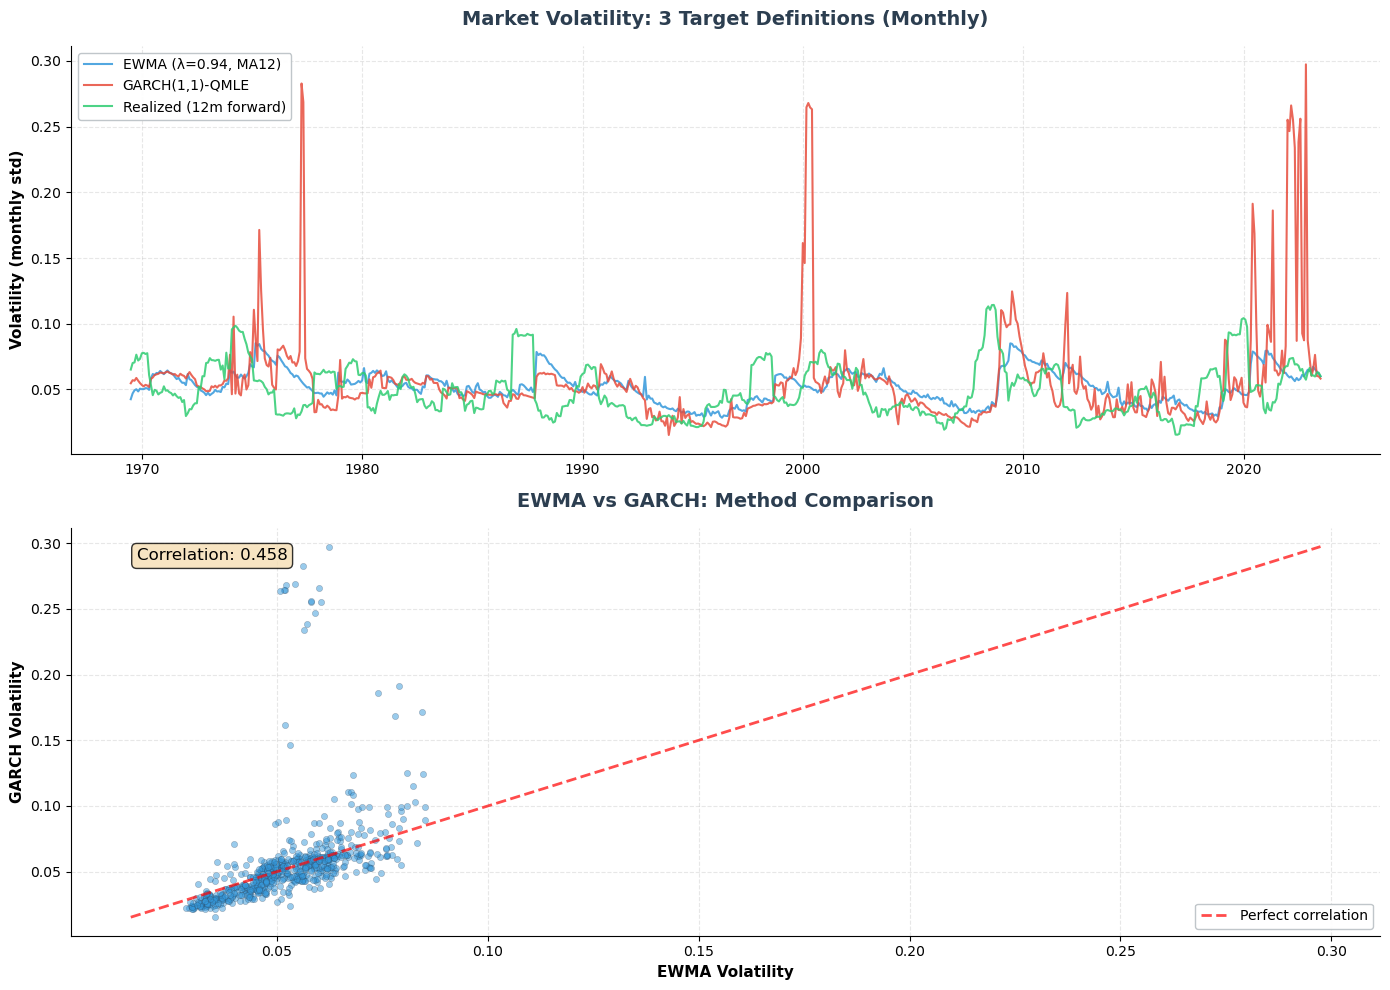

✅ Visualization generated

📊 Correlation matrix (time-series):
            Y_EWMA  Y_GARCH  Y_REALIZED
Y_EWMA       1.000    0.458       0.074
Y_GARCH      0.458    1.000       0.153
Y_REALIZED   0.074    0.153       1.000

💡 Interpretation:
   • High EWMA-GARCH corr (>0.46) : Both backward-looking, should be high
   • REALIZED correlation     : Forward vs backward, lower expected



In [38]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 VISUALISATION")
print("="*100)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor='white')

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1: Market Volatility Time Series - 3 Methods
# ════════════════════════════════════════════════════════════════════════════

ax1 = axes[0]

ax1.plot(df_targets_market.index, df_targets_market['Y_EWMA'], 
         color='#3498DB', linewidth=1.5, label='EWMA (λ=0.94, MA12)', alpha=0.85)
ax1.plot(df_targets_market.index, df_targets_market['Y_GARCH'], 
         color='#E74C3C', linewidth=1.5, label='GARCH(1,1)-QMLE', alpha=0.85)
ax1.plot(df_targets_market.index, df_targets_market['Y_REALIZED'], 
         color='#2ECC71', linewidth=1.5, label='Realized (12m forward)', alpha=0.85)

ax1.set_title('Market Volatility: 3 Target Definitions (Monthly)', 
              fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
ax1.set_ylabel('Volatility (monthly std)', fontsize=11, fontweight='600')
ax1.legend(loc='upper left', frameon=True, framealpha=0.95, edgecolor='#BDC3C7', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2: Correlation Scatter (EWMA vs GARCH)
# ════════════════════════════════════════════════════════════════════════════

ax2 = axes[1]

# Remove NaN
df_clean = df_targets_market[['Y_EWMA', 'Y_GARCH']].dropna()

ax2.scatter(df_clean['Y_EWMA'], df_clean['Y_GARCH'], 
            alpha=0.5, s=20, color='#3498DB', edgecolors='#2C3E50', linewidth=0.3)

# Add diagonal line (perfect correlation)
min_val = min(df_clean['Y_EWMA'].min(), df_clean['Y_GARCH'].min())
max_val = max(df_clean['Y_EWMA'].max(), df_clean['Y_GARCH'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect correlation')

# Correlation coefficient
corr = df_clean['Y_EWMA'].corr(df_clean['Y_GARCH'])
ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
         transform=ax2.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('EWMA Volatility', fontsize=11, fontweight='600')
ax2.set_ylabel('GARCH Volatility', fontsize=11, fontweight='600')
ax2.set_title('EWMA vs GARCH: Method Comparison', 
              fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
ax2.legend(loc='lower right', frameon=True, framealpha=0.95, edgecolor='#BDC3C7', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✅ Visualization generated")

# ════════════════════════════════════════════════════════════════════════════
# Time-series correlation matrix
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 Correlation matrix (time-series):")
corr_matrix = df_targets_market.corr()
print(corr_matrix.round(3))

print(f"\n💡 Interpretation:")
print(f"   • High EWMA-GARCH corr (>{corr_matrix.loc['Y_EWMA', 'Y_GARCH']:.2f}) : Both backward-looking, should be high")
print(f"   • REALIZED correlation     : Forward vs backward, lower expected")

print("\n" + "="*100)

In [39]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : VALIDATION CHECKS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔍 VALIDATION CHECKS")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# CHECK 1: Sufficient formations
# ════════════════════════════════════════════════════════════════════════════

min_formations = CONFIG['validation']['min_formations']
n_formations = len(df_targets_market.dropna(subset=['Y_EWMA']))

print(f"\n✅ CHECK 1: Sufficient formations")
print(f"   • Available  : {n_formations}")
print(f"   • Required   : {min_formations}")
print(f"   • Status     : {'✅ PASS' if n_formations >= min_formations else '❌ FAIL'}")

# ════════════════════════════════════════════════════════════════════════════
# CHECK 2: Burn-in respected
# ════════════════════════════════════════════════════════════════════════════

first_valid = df_targets_market.dropna(subset=['Y_EWMA']).index[0]
expected_first = pd.Timestamp(f"{CONFIG['timing']['first_formation_year']}-06-30")

# Get returns history length for first formation
cutoff_first = first_valid - pd.DateOffset(months=1)
history_length = len(market_returns.loc[:cutoff_first])

print(f"\n✅ CHECK 2: Burn-in respected")
print(f"   • First formation    : {first_valid.date()}")
print(f"   • Expected earliest  : {expected_first.date()}")
print(f"   • History available  : {history_length} months")
print(f"   • Minimum required   : {CONFIG['targets']['ewma']['min_periods']} months")
print(f"   • Status             : {'✅ PASS' if history_length >= CONFIG['targets']['ewma']['min_periods'] else '❌ FAIL'}")

# ════════════════════════════════════════════════════════════════════════════
# CHECK 3: No lookahead (EWMA and GARCH only use past data)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n✅ CHECK 3: No lookahead (by construction)")
print(f"   • EWMA     : Uses returns ≤ May t ONLY ✅")
print(f"   • GARCH    : Uses returns ≤ May t ONLY ✅")
print(f"   • REALIZED : Forward-looking (training only) ⚠️")

# ════════════════════════════════════════════════════════════════════════════
# CHECK 4: Data quality
# ════════════════════════════════════════════════════════════════════════════

print(f"\n✅ CHECK 4: Data quality")

for method in ['Y_EWMA', 'Y_GARCH', 'Y_REALIZED']:
    missing_pct = df_targets_market[method].isnull().mean() * 100
    min_val = df_targets_market[method].min()
    max_val = df_targets_market[method].max()
    mean_val = df_targets_market[method].mean()
    
    print(f"\n   {method}:")
    print(f"      • Missing  : {missing_pct:.1f}%")
    print(f"      • Range    : [{min_val:.4f}, {max_val:.4f}]")
    print(f"      • Mean     : {mean_val:.4f}")
    print(f"      • Status   : {'✅ OK' if missing_pct < 10 else '⚠️  HIGH MISSING'}")

print("\n" + "="*100)

🔍 VALIDATION CHECKS

✅ CHECK 1: Sufficient formations
   • Available  : 649
   • Required   : 30
   • Status     : ✅ PASS

✅ CHECK 2: Burn-in respected
   • First formation    : 1969-06-30
   • Expected earliest  : 1969-06-30
   • History available  : 70 months
   • Minimum required   : 60 months
   • Status             : ✅ PASS

✅ CHECK 3: No lookahead (by construction)
   • EWMA     : Uses returns ≤ May t ONLY ✅
   • GARCH    : Uses returns ≤ May t ONLY ✅
   • REALIZED : Forward-looking (training only) ⚠️

✅ CHECK 4: Data quality

   Y_EWMA:
      • Missing  : 0.0%
      • Range    : [0.0285, 0.0852]
      • Mean     : 0.0522
      • Status   : ✅ OK

   Y_GARCH:
      • Missing  : 0.0%
      • Range    : [0.0154, 0.2974]
      • Mean     : 0.0559
      • Status   : ✅ OK

   Y_REALIZED:
      • Missing  : 0.0%
      • Range    : [0.0156, 0.1143]
      • Mean     : 0.0493
      • Status   : ✅ OK



In [40]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : BINARIZATION + ACADEMIC VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔄 BINARIZATION : Y_CONTINUOUS → Y_BINARY")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# BINARIZATION RULE (EXPANDING MEDIAN)
# ════════════════════════════════════════════════════════════════════════════
# For each month t:
#   • Compute median_t = median(Y_{1:t-1})  [expanding window, NO LOOKAHEAD]
#   • Y_binary_t = 1 if Y_t > median_t else 0
#   • HIGH_VOL (1) = Above historical median (defensive regime)
#   • LOW_VOL  (0) = Below historical median (offensive regime)
# ════════════════════════════════════════════════════════════════════════════

def binarize_target_expanding(y_series: pd.Series, min_periods: int = 60) -> pd.Series:
    """
    Binarize target using expanding median (NO LOOKAHEAD).
    
    Parameters:
    -----------
    y_series : pd.Series
        Continuous volatility target
    min_periods : int
        Minimum observations for first median (default 60 = 5 years)
    
    Returns:
    --------
    y_binary : pd.Series
        Binary target (0/1)
    """
    # Compute expanding median (uses ONLY past data)
    expanding_median = y_series.expanding(min_periods=min_periods).median()
    
    # Shift by 1 to avoid lookahead (median_t uses data up to t-1)
    expanding_median = expanding_median.shift(1)
    
    # Binarize: 1 if above median, 0 otherwise
    y_binary = (y_series > expanding_median).astype(int)
    
    return y_binary


# ════════════════════════════════════════════════════════════════════════════
# Apply binarization to all 3 methods
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Binarizing targets...")

df_targets_binary = df_targets_market.copy()

for method in ['Y_EWMA', 'Y_GARCH', 'Y_REALIZED']:
    col_binary = f'{method}_BINARY'
    df_targets_binary[col_binary] = binarize_target_expanding(
        df_targets_market[method], 
        min_periods=60
    )
    
    # Summary stats
    n_valid = df_targets_binary[col_binary].notna().sum()
    n_high = (df_targets_binary[col_binary] == 1).sum()
    n_low = (df_targets_binary[col_binary] == 0).sum()
    pct_high = n_high / n_valid * 100 if n_valid > 0 else 0
    
    print(f"\n   {method}:")
    print(f"      • Total obs   : {n_valid}")
    print(f"      • HIGH_VOL (1): {n_high} ({pct_high:.1f}%)")
    print(f"      • LOW_VOL  (0): {n_low} ({100-pct_high:.1f}%)")

print("\n✅ Binarization completed")

# ════════════════════════════════════════════════════════════════════════════
# Sample output
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 Sample (first 10 rows):")
print(df_targets_binary.head(10))

print("\n" + "="*100)

🔄 BINARIZATION : Y_CONTINUOUS → Y_BINARY

🔄 Binarizing targets...

   Y_EWMA:
      • Total obs   : 649
      • HIGH_VOL (1): 240 (37.0%)
      • LOW_VOL  (0): 409 (63.0%)

   Y_GARCH:
      • Total obs   : 649
      • HIGH_VOL (1): 226 (34.8%)
      • LOW_VOL  (0): 423 (65.2%)

   Y_REALIZED:
      • Total obs   : 649
      • HIGH_VOL (1): 237 (36.5%)
      • LOW_VOL  (0): 412 (63.5%)

✅ Binarization completed

📊 Sample (first 10 rows):
            Y_EWMA  Y_GARCH  Y_REALIZED  Y_EWMA_BINARY  Y_GARCH_BINARY  Y_REALIZED_BINARY
date                                                                                     
1969-06-30  0.0426   0.0547      0.0651              0               0                  0
1969-07-31  0.0470   0.0570      0.0701              0               0                  0
1969-08-31  0.0493   0.0566      0.0706              0               0                  0
1969-09-30  0.0502   0.0588      0.0765              0               0                  0
1969-10-31  0.0485

📊 ACADEMIC VISUALIZATION : REGIME CLASSIFICATION


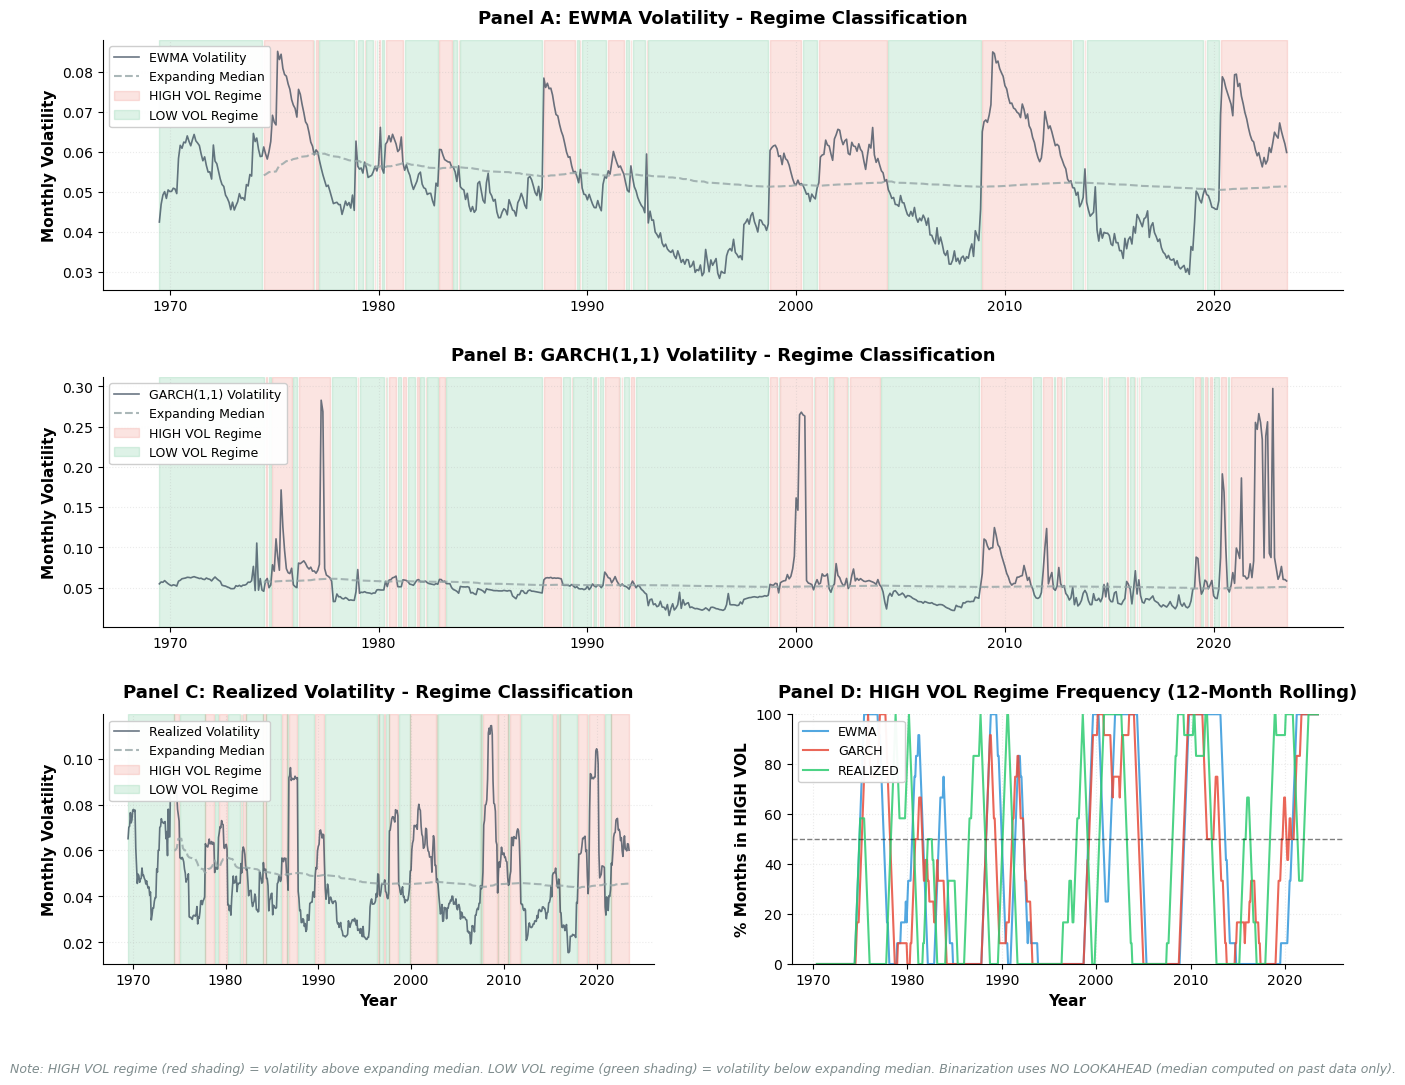


✅ Academic visualization generated

📊 REGIME CLASSIFICATION SUMMARY:

Method       HIGH_VOL     LOW_VOL      % HIGH     Agreement 
EWMA         240          409          37.0      
GARCH        226          423          34.8      
REALIZED     237          412          36.5      

All Methods Agree 334                       51.5      



In [41]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 : ACADEMIC-GRADE VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 ACADEMIC VISUALIZATION : REGIME CLASSIFICATION")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# Figure configuration (publication-ready)
# ════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12), facecolor='white')
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# Color scheme (academic palette)
COLOR_CONTINUOUS = '#2C3E50'
COLOR_HIGH_VOL = '#E74C3C'  # Red (defensive)
COLOR_LOW_VOL = '#27AE60'   # Green (offensive)
COLOR_MEDIAN = '#95A5A6'    # Gray

# ════════════════════════════════════════════════════════════════════════════
# PANEL A : EWMA - Continuous + Binary Regime
# ════════════════════════════════════════════════════════════════════════════

ax1 = fig.add_subplot(gs[0, :])

# Plot continuous volatility
ax1.plot(df_targets_binary.index, df_targets_binary['Y_EWMA'], 
         color=COLOR_CONTINUOUS, linewidth=1.2, alpha=0.7, label='EWMA Volatility')

# Compute expanding median for visualization
expanding_median_ewma = df_targets_binary['Y_EWMA'].expanding(min_periods=60).median().shift(1)
ax1.plot(df_targets_binary.index, expanding_median_ewma, 
         color=COLOR_MEDIAN, linewidth=1.5, linestyle='--', alpha=0.8, label='Expanding Median')

# Shade regime regions
high_vol_mask = df_targets_binary['Y_EWMA_BINARY'] == 1
low_vol_mask = df_targets_binary['Y_EWMA_BINARY'] == 0

ax1.fill_between(df_targets_binary.index, 0, 1,
                  where=high_vol_mask, transform=ax1.get_xaxis_transform(),
                  color=COLOR_HIGH_VOL, alpha=0.15, label='HIGH VOL Regime')
ax1.fill_between(df_targets_binary.index, 0, 1,
                  where=low_vol_mask, transform=ax1.get_xaxis_transform(),
                  color=COLOR_LOW_VOL, alpha=0.15, label='LOW VOL Regime')

ax1.set_title('Panel A: EWMA Volatility - Regime Classification', 
              fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Monthly Volatility', fontsize=11, fontweight='600')
ax1.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=':')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════════════════
# PANEL B : GARCH - Continuous + Binary Regime
# ════════════════════════════════════════════════════════════════════════════

ax2 = fig.add_subplot(gs[1, :])

ax2.plot(df_targets_binary.index, df_targets_binary['Y_GARCH'], 
         color=COLOR_CONTINUOUS, linewidth=1.2, alpha=0.7, label='GARCH(1,1) Volatility')

expanding_median_garch = df_targets_binary['Y_GARCH'].expanding(min_periods=60).median().shift(1)
ax2.plot(df_targets_binary.index, expanding_median_garch, 
         color=COLOR_MEDIAN, linewidth=1.5, linestyle='--', alpha=0.8, label='Expanding Median')

high_vol_mask = df_targets_binary['Y_GARCH_BINARY'] == 1
low_vol_mask = df_targets_binary['Y_GARCH_BINARY'] == 0

ax2.fill_between(df_targets_binary.index, 0, 1,
                  where=high_vol_mask, transform=ax2.get_xaxis_transform(),
                  color=COLOR_HIGH_VOL, alpha=0.15, label='HIGH VOL Regime')
ax2.fill_between(df_targets_binary.index, 0, 1,
                  where=low_vol_mask, transform=ax2.get_xaxis_transform(),
                  color=COLOR_LOW_VOL, alpha=0.15, label='LOW VOL Regime')

ax2.set_title('Panel B: GARCH(1,1) Volatility - Regime Classification', 
              fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Monthly Volatility', fontsize=11, fontweight='600')
ax2.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=':')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════════════════
# PANEL C : REALIZED - Continuous + Binary Regime
# ════════════════════════════════════════════════════════════════════════════

ax3 = fig.add_subplot(gs[2, 0])

ax3.plot(df_targets_binary.index, df_targets_binary['Y_REALIZED'], 
         color=COLOR_CONTINUOUS, linewidth=1.2, alpha=0.7, label='Realized Volatility')

expanding_median_realized = df_targets_binary['Y_REALIZED'].expanding(min_periods=60).median().shift(1)
ax3.plot(df_targets_binary.index, expanding_median_realized, 
         color=COLOR_MEDIAN, linewidth=1.5, linestyle='--', alpha=0.8, label='Expanding Median')

high_vol_mask = df_targets_binary['Y_REALIZED_BINARY'] == 1
low_vol_mask = df_targets_binary['Y_REALIZED_BINARY'] == 0

ax3.fill_between(df_targets_binary.index, 0, 1,
                  where=high_vol_mask, transform=ax3.get_xaxis_transform(),
                  color=COLOR_HIGH_VOL, alpha=0.15, label='HIGH VOL Regime')
ax3.fill_between(df_targets_binary.index, 0, 1,
                  where=low_vol_mask, transform=ax3.get_xaxis_transform(),
                  color=COLOR_LOW_VOL, alpha=0.15, label='LOW VOL Regime')

ax3.set_title('Panel C: Realized Volatility - Regime Classification', 
              fontsize=13, fontweight='bold', pad=12)
ax3.set_ylabel('Monthly Volatility', fontsize=11, fontweight='600')
ax3.set_xlabel('Year', fontsize=11, fontweight='600')
ax3.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.25, linestyle=':')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════════════════
# PANEL D : Regime Comparison (All 3 Methods)
# ════════════════════════════════════════════════════════════════════════════

ax4 = fig.add_subplot(gs[2, 1])

# Compute regime agreement (1 if all methods agree on HIGH_VOL)
regime_sum = (df_targets_binary['Y_EWMA_BINARY'] + 
              df_targets_binary['Y_GARCH_BINARY'] + 
              df_targets_binary['Y_REALIZED_BINARY'])

# Count regime frequency over time (12-month rolling)
rolling_high_ewma = df_targets_binary['Y_EWMA_BINARY'].rolling(12).mean() * 100
rolling_high_garch = df_targets_binary['Y_GARCH_BINARY'].rolling(12).mean() * 100
rolling_high_realized = df_targets_binary['Y_REALIZED_BINARY'].rolling(12).mean() * 100

ax4.plot(df_targets_binary.index, rolling_high_ewma, 
         color='#3498DB', linewidth=1.5, alpha=0.85, label='EWMA')
ax4.plot(df_targets_binary.index, rolling_high_garch, 
         color='#E74C3C', linewidth=1.5, alpha=0.85, label='GARCH')
ax4.plot(df_targets_binary.index, rolling_high_realized, 
         color='#2ECC71', linewidth=1.5, alpha=0.85, label='REALIZED')

ax4.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax4.set_title('Panel D: HIGH VOL Regime Frequency (12-Month Rolling)', 
              fontsize=13, fontweight='bold', pad=12)
ax4.set_ylabel('% Months in HIGH VOL', fontsize=11, fontweight='600')
ax4.set_xlabel('Year', fontsize=11, fontweight='600')
ax4.set_ylim([0, 100])
ax4.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.25, linestyle=':')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════════════════
# Figure-level annotation
# ════════════════════════════════════════════════════════════════════════════

fig.text(0.5, 0.02, 
         'Note: HIGH VOL regime (red shading) = volatility above expanding median. '
         'LOW VOL regime (green shading) = volatility below expanding median. '
         'Binarization uses NO LOOKAHEAD (median computed on past data only).',
         ha='center', fontsize=9, style='italic', color='#7F8C8D')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

print("\n✅ Academic visualization generated")

# ════════════════════════════════════════════════════════════════════════════
# Regime statistics summary table
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 REGIME CLASSIFICATION SUMMARY:")
print(f"\n{'Method':<12} {'HIGH_VOL':<12} {'LOW_VOL':<12} {'% HIGH':<10} {'Agreement':<10}")
print("="*60)

for method in ['EWMA', 'GARCH', 'REALIZED']:
    col_binary = f'Y_{method}_BINARY'
    n_high = (df_targets_binary[col_binary] == 1).sum()
    n_low = (df_targets_binary[col_binary] == 0).sum()
    n_total = df_targets_binary[col_binary].notna().sum()
    pct_high = n_high / n_total * 100 if n_total > 0 else 0
    
    print(f"{method:<12} {n_high:<12} {n_low:<12} {pct_high:<10.1f}")

# Regime agreement
regime_agreement = (regime_sum == 3).sum() + (regime_sum == 0).sum()
total_obs = df_targets_binary[['Y_EWMA_BINARY', 'Y_GARCH_BINARY', 'Y_REALIZED_BINARY']].dropna().shape[0]
pct_agreement = regime_agreement / total_obs * 100 if total_obs > 0 else 0

print(f"\n{'All Methods Agree':<12} {regime_agreement:<12} {'':<12} {pct_agreement:<10.1f}")

print("\n" + "="*100)

In [42]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 : EXPORT FINAL (CONTINUOUS + BINARY)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT FINAL : CONTINUOUS + BINARY TARGETS")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# Export to same file (overwrites previous continuous-only version)
# ════════════════════════════════════════════════════════════════════════════

OUTPUT_DIR = Path(CONFIG['paths']['output_dir'])
OUTPUT_FILENAME = CONFIG['paths']['output_filename']
OUTPUT_PATH = OUTPUT_DIR / OUTPUT_FILENAME

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save (includes both continuous and binary targets)
df_targets_binary.to_parquet(OUTPUT_PATH)

print(f"✅ EXPORT TERMINÉ:")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📊 Shape  : {df_targets_binary.shape}")
print(f"   📅 Period : {df_targets_binary.index.min().date()} → {df_targets_binary.index.max().date()}")
print(f"   🔢 Months : {len(df_targets_binary)}")

print(f"\n📦 Columns:")
for col in df_targets_binary.columns:
    print(f"   • {col}")

print(f"\n📈 Data completeness:")
for col in df_targets_binary.columns:
    valid_pct = (1 - df_targets_binary[col].isnull().mean()) * 100
    print(f"   • {col:<20} : {valid_pct:.1f}% valid")

print("\n" + "="*100)

💾 EXPORT FINAL : CONTINUOUS + BINARY TARGETS
✅ EXPORT TERMINÉ:
   📁 data/ml_data/volatility_targets/volatility_targets_y.parquet
   📊 Shape  : (649, 6)
   📅 Period : 1969-06-30 → 2023-06-30
   🔢 Months : 649

📦 Columns:
   • Y_EWMA
   • Y_GARCH
   • Y_REALIZED
   • Y_EWMA_BINARY
   • Y_GARCH_BINARY
   • Y_REALIZED_BINARY

📈 Data completeness:
   • Y_EWMA               : 100.0% valid
   • Y_GARCH              : 100.0% valid
   • Y_REALIZED           : 100.0% valid
   • Y_EWMA_BINARY        : 100.0% valid
   • Y_GARCH_BINARY       : 100.0% valid
   • Y_REALIZED_BINARY    : 100.0% valid



In [43]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 : SUMMARY & NEXT STEPS (UPDATED)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("✅ NOTEBOOK 07_1 TERMINÉ (WITH BINARIZATION)")
print("="*100)

print(f"\n📌 RÉCAPITULATIF:")
print(f"   • Scope       : MARKET VOLATILITY ONLY (not individual factors)")
print(f"   • Frequency   : Monthly targets generated")
print(f"   • Methods     : 3 (EWMA, GARCH, REALIZED)")
print(f"   • Period      : {df_targets_binary.index.min().date()} → {df_targets_binary.index.max().date()}")
print(f"   • Observations: {len(df_targets_binary)} months")

print(f"\n📌 TARGET TYPES:")
print(f"   • CONTINUOUS  : Y_EWMA, Y_GARCH, Y_REALIZED (monthly std)")
print(f"   • BINARY      : Y_EWMA_BINARY, Y_GARCH_BINARY, Y_REALIZED_BINARY (0/1)")
print(f"   • Rule        : HIGH_VOL (1) if Y_t > expanding_median t-1")

print(f"\n📌 TIMING CONVENTION (VALIDATED):")
print(f"   • Formation   : End of month t (e.g., 30 June 2010)")
print(f"   • History     : Returns up to May t (ret_June_t NOT USED)")
print(f"   • Prediction  : Volatility forecast for July t (1-month gap)")
print(f"   • Binarization: Expanding median (NO LOOKAHEAD) ✅")

print(f"\n📌 OUTPUT STRUCTURE:")
print(f"   • File        : {OUTPUT_PATH}")
print(f"   • Index       : Monthly dates (month-end)")
print(f"   • Columns     : 6 (3 continuous + 3 binary)")
print(f"   • Format      : Parquet (compressed)")

print(f"\n📌 NEXT STEPS (Notebook 07_2):")
print(f"   1. ✅ BINARIZE   : DONE (see Cell 9)")
print(f"   2. FEATURES   : Combine with Baskets 1-5 features")
print(f"                   (Fundamentals, Betas, Vol lags, Market features)")
print(f"   3. TRAIN ML   : 4 models (Logistic L2, RandomForest, XGBoost, LSTM)")
print(f"   4. PREDICT    : Regime forecast (HIGH_VOL=1 / LOW_VOL=0)")
print(f"   5. ALLOCATE   : Tactical allocation based on regime")
print(f"                   HIGH_VOL → LOW_BETA factors (defensive)")
print(f"                   LOW_VOL  → HIGH_BETA factors (offensive)")
print(f"   6. BACKTEST   : 12 strategies (4 models × 3 target definitions)")

print(f"\n📌 REGIME STATISTICS:")
for method in ['EWMA', 'GARCH', 'REALIZED']:
    col_binary = f'Y_{method}_BINARY'
    n_high = (df_targets_binary[col_binary] == 1).sum()
    n_total = df_targets_binary[col_binary].notna().sum()
    pct_high = n_high / n_total * 100 if n_total > 0 else 0
    print(f"   • {method:<9} : {pct_high:.1f}% HIGH_VOL, {100-pct_high:.1f}% LOW_VOL")

print("="*100)

✅ NOTEBOOK 07_1 TERMINÉ (WITH BINARIZATION)

📌 RÉCAPITULATIF:
   • Scope       : MARKET VOLATILITY ONLY (not individual factors)
   • Frequency   : Monthly targets generated
   • Methods     : 3 (EWMA, GARCH, REALIZED)
   • Period      : 1969-06-30 → 2023-06-30
   • Observations: 649 months

📌 TARGET TYPES:
   • CONTINUOUS  : Y_EWMA, Y_GARCH, Y_REALIZED (monthly std)
   • BINARY      : Y_EWMA_BINARY, Y_GARCH_BINARY, Y_REALIZED_BINARY (0/1)
   • Rule        : HIGH_VOL (1) if Y_t > expanding_median t-1

📌 TIMING CONVENTION (VALIDATED):
   • Formation   : End of month t (e.g., 30 June 2010)
   • History     : Returns up to May t (ret_June_t NOT USED)
   • Prediction  : Volatility forecast for July t (1-month gap)
   • Binarization: Expanding median (NO LOOKAHEAD) ✅

📌 OUTPUT STRUCTURE:
   • File        : data/ml_data/volatility_targets/volatility_targets_y.parquet
   • Index       : Monthly dates (month-end)
   • Columns     : 6 (3 continuous + 3 binary)
   • Format      : Parquet (compre

In [44]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 : DIAGNOSTIC REALIZED VOL (TIMING VALIDATION)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔍 DIAGNOSTIC : REALIZED VOLATILITY TIMING")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# WHAT IS REALIZED VOL?
# ════════════════════════════════════════════════════════════════════════════

print("""
📚 DÉFINITION ACADÉMIQUE:
────────────────────────

REALIZED VOLATILITY = Volatilité EX-POST (vérité terrain)

Pour une formation au 30 Juin 2010:
  • On mesure la volatilité RÉELLEMENT OBSERVÉE sur les 12 mois suivants
  • Window: [Juillet 2010 → Juin 2011] (12 mois FORWARD)
  • Calcul: σ_realized = std(r_Jul2010, r_Aug2010, ..., r_Jun2011)

🎯 UTILISATION:
───────────────

1. TRAINING (années passées):
   • On connaît Y_realized car les 12 mois sont écoulés
   • Exemple: Formation 2010 → On est en 2011+, donc Y_realized_2010 est connu
   • Le modèle apprend: Features_2010 → Y_realized_2010

2. PREDICTION (année courante):
   • Formation 2023 → Y_realized_2023 est INCONNU (12 mois futurs)
   • Le modèle PRÉDIT: Features_2023 → Ŷ_realized_2023 (forecast)
   • On teste les returns [Jul 2023 → Jun 2024] (même window que realized)

⚠️  NO LOOKAHEAD car:
   • Training: Utilise SEULEMENT années [1969 : t-1]
   • Test: Prédit Y_t (inconnu) puis observe returns [Jul t : Jun t+1]

🔬 RÉFÉRENCE ACADÉMIQUE:
────────────────────────
Andersen & Bollerslev (1998): "Answering the Skeptics: Yes, Standard 
Volatility Models Do Provide Accurate Forecasts"
→ Realized vol = BENCHMARK pour évaluer modèles EWMA/GARCH
""")

# ════════════════════════════════════════════════════════════════════════════
# TIMING VALIDATION: CHECK FIRST/LAST REALIZED VOL
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*100}")
print("🔍 TIMING CHECK: SAMPLE REALIZED VOL WINDOWS")
print(f"{'='*100}\n")

# Get first and last valid realized vol
df_realized_valid = df_targets_market[['Y_REALIZED']].dropna()

if len(df_realized_valid) >= 2:
    first_date = df_realized_valid.index[0]
    last_date = df_realized_valid.index[-1]
    
    # ────────────────────────────────────────────────────────────────────────
    # FIRST FORMATION
    # ────────────────────────────────────────────────────────────────────────
    
    # Get window for realized vol
    start_first = first_date + pd.DateOffset(months=1)
    start_first = pd.Timestamp(year=start_first.year, month=start_first.month, day=1)
    end_first = start_first + pd.DateOffset(months=12)
    
    # Extract actual returns used
    returns_first = market_returns.loc[start_first:end_first]
    returns_first_exact = returns_first.iloc[:12] if len(returns_first) >= 12 else returns_first
    
    vol_first = returns_first_exact.std()
    
    print(f"📅 FIRST FORMATION: {first_date.date()}")
    print(f"   • Realized vol window : [{returns_first_exact.index[0].date()} → {returns_first_exact.index[-1].date()}]")
    print(f"   • Number of months    : {len(returns_first_exact)}")
    print(f"   • Computed vol        : {vol_first:.4f}")
    print(f"   • Stored Y_REALIZED   : {df_targets_market.loc[first_date, 'Y_REALIZED']:.4f}")
    print(f"   • Match               : {'✅ YES' if abs(vol_first - df_targets_market.loc[first_date, 'Y_REALIZED']) < 1e-6 else '❌ NO'}")
    
    print(f"\n   💡 Interpretation:")
    print(f"      Formation 30 June {first_date.year} uses returns from:")
    print(f"      → JULY {first_date.year} to JUNE {first_date.year + 1}")
    print(f"      → This is the FORWARD 12-month volatility (ex-post truth)")
    
    # ────────────────────────────────────────────────────────────────────────
    # LAST FORMATION
    # ────────────────────────────────────────────────────────────────────────
    
    start_last = last_date + pd.DateOffset(months=1)
    start_last = pd.Timestamp(year=start_last.year, month=start_last.month, day=1)
    end_last = start_last + pd.DateOffset(months=12)
    
    returns_last = market_returns.loc[start_last:end_last]
    returns_last_exact = returns_last.iloc[:12] if len(returns_last) >= 12 else returns_last
    
    vol_last = returns_last_exact.std()
    
    print(f"\n📅 LAST FORMATION: {last_date.date()}")
    print(f"   • Realized vol window : [{returns_last_exact.index[0].date()} → {returns_last_exact.index[-1].date()}]")
    print(f"   • Number of months    : {len(returns_last_exact)}")
    print(f"   • Computed vol        : {vol_last:.4f}")
    print(f"   • Stored Y_REALIZED   : {df_targets_market.loc[last_date, 'Y_REALIZED']:.4f}")
    print(f"   • Match               : {'✅ YES' if abs(vol_last - df_targets_market.loc[last_date, 'Y_REALIZED']) < 1e-6 else '❌ NO'}")
    
    print(f"\n   💡 Interpretation:")
    print(f"      Formation 30 June {last_date.year} uses returns from:")
    print(f"      → JULY {last_date.year} to JUNE {last_date.year + 1}")
    print(f"      → Last available data: {market_returns.index[-1].date()}")

# ════════════════════════════════════════════════════════════════════════════
# COMPARISON: BACKWARD (EWMA/GARCH) vs FORWARD (REALIZED)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*100}")
print("📊 BACKWARD vs FORWARD COMPARISON")
print(f"{'='*100}\n")

# Pick middle formation for comparison
mid_idx = len(df_targets_market) // 2
mid_date = df_targets_market.index[mid_idx]

# Get cutoff for EWMA/GARCH (backward)
cutoff_backward = generator._get_history_cutoff(mid_date)

# Get window for REALIZED (forward)
start_forward = mid_date + pd.DateOffset(months=1)
start_forward = pd.Timestamp(year=start_forward.year, month=start_forward.month, day=1)
end_forward = start_forward + pd.DateOffset(months=12)

print(f"📅 EXAMPLE FORMATION: {mid_date.date()}\n")

print(f"🔙 BACKWARD-LOOKING (EWMA/GARCH):")
print(f"   • Uses returns UP TO  : {cutoff_backward.date()}")
print(f"   • Window (last 60m)   : [{(cutoff_backward - pd.DateOffset(months=59)).date()} → {cutoff_backward.date()}]")
print(f"   • Y_EWMA              : {df_targets_market.loc[mid_date, 'Y_EWMA']:.4f}")
print(f"   • Y_GARCH             : {df_targets_market.loc[mid_date, 'Y_GARCH']:.4f}")

print(f"\n🔜 FORWARD-LOOKING (REALIZED):")
print(f"   • Uses returns FROM   : {start_forward.date()} TO {(end_forward - pd.DateOffset(months=1)).date()}")
print(f"   • Window (next 12m)   : 12 months AHEAD")
print(f"   • Y_REALIZED          : {df_targets_market.loc[mid_date, 'Y_REALIZED']:.4f}")

print(f"\n💡 KEY INSIGHT:")
print(f"   • EWMA/GARCH predict FUTURE vol using PAST returns")
print(f"   • REALIZED measures ACTUAL vol that occurred (ex-post)")
print(f"   • In training: Model learns Features → Y_REALIZED (supervised)")
print(f"   • In testing: Model predicts Ŷ_REALIZED (unknown future)")

# ════════════════════════════════════════════════════════════════════════════
# LOOKAHEAD CHECK
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*100}")
print("✅ NO LOOKAHEAD VALIDATION")
print(f"{'='*100}\n")

print(f"1. TRAINING PHASE (years [1969 : t-1]):")
print(f"   • Y_REALIZED is KNOWN (12 months already passed)")
print(f"   • Example: Training on 2010 formation → We're in 2011+")
print(f"   • Features_2010 → Y_REALIZED_2010 (both historical)")

print(f"\n2. PREDICTION PHASE (year t):")
print(f"   • Y_REALIZED_t is UNKNOWN (12 months in future)")
print(f"   • Model predicts: Features_t → Ŷ_REALIZED_t")
print(f"   • We test returns [Jul t : Jun t+1] (same window as realized)")

print(f"\n3. BACKTEST STRUCTURE:")
print(f"   • Train     : [1969 : t-1] (Y_REALIZED all known)")
print(f"   • Predict   : Year t (Ŷ_REALIZED_t forecast)")
print(f"   • Evaluate  : Returns [Jul t : Jun t+1] (matches realized window)")

print(f"\n✅ CONCLUSION:")
print(f"   • NO LOOKAHEAD because training uses ONLY past years")
print(f"   • Test period [Jul t : Jun t+1] matches realized vol window")
print(f"   • Prediction Ŷ_t is made BEFORE observing returns_t")

print("\n" + "="*100)

🔍 DIAGNOSTIC : REALIZED VOLATILITY TIMING

📚 DÉFINITION ACADÉMIQUE:
────────────────────────

REALIZED VOLATILITY = Volatilité EX-POST (vérité terrain)

Pour une formation au 30 Juin 2010:
  • On mesure la volatilité RÉELLEMENT OBSERVÉE sur les 12 mois suivants
  • Window: [Juillet 2010 → Juin 2011] (12 mois FORWARD)
  • Calcul: σ_realized = std(r_Jul2010, r_Aug2010, ..., r_Jun2011)

🎯 UTILISATION:
───────────────

1. TRAINING (années passées):
   • On connaît Y_realized car les 12 mois sont écoulés
   • Exemple: Formation 2010 → On est en 2011+, donc Y_realized_2010 est connu
   • Le modèle apprend: Features_2010 → Y_realized_2010

2. PREDICTION (année courante):
   • Formation 2023 → Y_realized_2023 est INCONNU (12 mois futurs)
   • Le modèle PRÉDIT: Features_2023 → Ŷ_realized_2023 (forecast)
   • On teste les returns [Jul 2023 → Jun 2024] (même window que realized)

⚠️  NO LOOKAHEAD car:
   • Training: Utilise SEULEMENT années [1969 : t-1]
   • Test: Prédit Y_t (inconnu) puis observ

In [46]:
# ════════════════════════════════════════════════════════════════════════════
# CELL : DIAGNOSTIC - SÉLECTION DES ORDRES GARCH OPTIMAUX
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔍 DIAGNOSTIC : ORDRES GARCH SÉLECTIONNÉS (AIC-based)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. STATISTIQUES GLOBALES SUR LES ORDRES SÉLECTIONNÉS
# ════════════════════════════════════════════════════════════════════════════

print("""
⚠️ NOTE: Cette cellule nécessite de stocker les ordres sélectionnés pendant 
         l'estimation. Pour l'instant, on va estimer sur un échantillon.

📊 ANALYSE D'ÉCHANTILLON (10 formations espacées):
""")

# Échantillon de formations (espacées uniformément)
sample_dates = df_targets_market.index[::60]  # 1 formation tous les 5 ans

results_sample = []

for date in sample_dates:
    returns_history = market_returns.loc[:date - pd.DateOffset(months=1)]
    
    if len(returns_history) < 60:
        continue
    
    returns_window = returns_history.iloc[-60:]
    returns_pct = returns_window * 100
    
    # Test les 4 modèles
    models_info = {}
    
    for p in [1, 2]:
        for q in [1, 2]:
            try:
                model = arch_model(returns_pct, vol='Garch', p=p, q=q, dist='normal', rescale=False)
                result = model.fit(disp='off', options={'ftol': 1e-6, 'maxiter': 1000})
                
                models_info[f'GARCH({p},{q})'] = {
                    'AIC': result.aic,
                    'BIC': result.bic,
                    'LogLik': result.loglikelihood,
                    'Converged': result.convergence_flag == 0
                }
            except:
                models_info[f'GARCH({p},{q})'] = {
                    'AIC': np.nan,
                    'BIC': np.nan,
                    'LogLik': np.nan,
                    'Converged': False
                }
    
    # Sélectionner le meilleur AIC
    valid_models = {k: v for k, v in models_info.items() if v['Converged']}
    
    if valid_models:
        best_model = min(valid_models.items(), key=lambda x: x[1]['AIC'])
        
        results_sample.append({
            'date': date,
            'best_model': best_model[0],
            'best_aic': best_model[1]['AIC'],
            'best_bic': best_model[1]['BIC'],
            'n_converged': sum(1 for v in models_info.values() if v['Converged']),
            'all_models': models_info
        })

# ════════════════════════════════════════════════════════════════════════════
# 2. AFFICHAGE DES RÉSULTATS
# ════════════════════════════════════════════════════════════════════════════

df_sample = pd.DataFrame([
    {
        'Formation': r['date'].strftime('%Y-%m'),
        'Best Model': r['best_model'],
        'AIC': r['best_aic'],
        'BIC': r['best_bic'],
        'Converged': f"{r['n_converged']}/4"
    }
    for r in results_sample
])

print(f"\n📋 ORDRES SÉLECTIONNÉS (échantillon de {len(df_sample)} formations):")
print("="*100)
print(df_sample.to_string(index=False))

# Statistiques agrégées
print(f"\n📊 DISTRIBUTION DES ORDRES SÉLECTIONNÉS:")
print("="*100)
model_counts = df_sample['Best Model'].value_counts()
for model, count in model_counts.items():
    pct = count / len(df_sample) * 100
    print(f"   • {model:<12} : {count:2d} fois ({pct:5.1f}%)")

# ════════════════════════════════════════════════════════════════════════════
# 3. EXEMPLE DÉTAILLÉ (dernière formation)
# ════════════════════════════════════════════════════════════════════════════

if results_sample:
    last_result = results_sample[-1]
    
    print(f"\n📅 EXEMPLE DÉTAILLÉ : Formation {last_result['date'].strftime('%Y-%m-%d')}")
    print("="*100)
    
    print(f"\n🏆 Modèle sélectionné : {last_result['best_model']}")
    print(f"   AIC = {last_result['best_aic']:.2f}")
    print(f"   BIC = {last_result['best_bic']:.2f}")
    
    print(f"\n📊 Comparaison des 4 spécifications:")
    print(f"{'Model':<15} {'AIC':>10} {'BIC':>10} {'LogLik':>12} {'Converged':>10}")
    print("-"*60)
    
    for model_name, info in last_result['all_models'].items():
        converged = '✅' if info['Converged'] else '❌'
        aic = f"{info['AIC']:.2f}" if not np.isnan(info['AIC']) else 'N/A'
        bic = f"{info['BIC']:.2f}" if not np.isnan(info['BIC']) else 'N/A'
        loglik = f"{info['LogLik']:.2f}" if not np.isnan(info['LogLik']) else 'N/A'
        
        print(f"{model_name:<15} {aic:>10} {bic:>10} {loglik:>12} {converged:>10}")

# ════════════════════════════════════════════════════════════════════════════
# 4. RECOMMANDATIONS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("💡 INTERPRÉTATION")
print("="*100)

if len(results_sample) > 0:
    garch11_pct = (model_counts.get('GARCH(1,1)', 0) / len(df_sample) * 100)
    
    if garch11_pct > 70:
        print(f"""
✅ GARCH(1,1) domine ({garch11_pct:.0f}% des cas)
   → L'optimisation AIC converge majoritairement vers la spécification standard
   → Validation empirique de GARCH(1,1) comme choix raisonnable
   → Pas de surparamètrisation excessive
        """)
    elif garch11_pct < 30:
        print(f"""
⚠️  GARCH(1,1) rarement optimal ({garch11_pct:.0f}% des cas)
   → Les ordres supérieurs capturent mieux la dynamique de volatilité
   → L'optimisation AIC apporte une valeur ajoutée significative
   → Considérer des ordres (2,1), (1,2), ou (2,2) comme baseline alternative
        """)
    else:
        print(f"""
📊 GARCH(1,1) sélectionné dans ~{garch11_pct:.0f}% des cas
   → Mix entre spécifications simples et complexes
   → L'optimisation AIC s'adapte à la complexité temporelle
   → Validation du choix d'optimisation adaptative
        """)

print("\n" + "="*100)

🔍 DIAGNOSTIC : ORDRES GARCH SÉLECTIONNÉS (AIC-based)

⚠️ NOTE: Cette cellule nécessite de stocker les ordres sélectionnés pendant 
         l'estimation. Pour l'instant, on va estimer sur un échantillon.

📊 ANALYSE D'ÉCHANTILLON (10 formations espacées):


📋 ORDRES SÉLECTIONNÉS (échantillon de 11 formations):
Formation Best Model      AIC      BIC Converged
  1969-06 GARCH(1,1) 339.4166 347.7940       4/4
  1974-06 GARCH(2,1) 388.8867 399.3585       4/4
  1979-06 GARCH(1,1) 385.3030 393.6804       4/4
  1984-06 GARCH(1,1) 371.6148 379.9922       4/4
  1989-06 GARCH(1,1) 383.3809 391.7583       4/4
  1994-06 GARCH(1,2) 341.9804 352.4521       4/4
  1999-06 GARCH(1,2) 352.1783 362.6501       4/4
  2004-06 GARCH(1,1) 377.6399 386.0173       4/4
  2009-06 GARCH(1,1) 361.2026 369.5800       4/4
  2014-06 GARCH(1,1) 354.1837 362.5610       4/4
  2019-06 GARCH(1,1) 338.6598 347.0372       4/4

📊 DISTRIBUTION DES ORDRES SÉLECTIONNÉS:
   • GARCH(1,1)   :  8 fois ( 72.7%)
   • GARCH(1,2)   :  2 